In [52]:
import os
import glob
import pandas as pd
from functools import reduce

# Project paths
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW_DIR:", DATA_RAW_DIR)

PROJECT_ROOT: c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\StocksClassification
DATA_RAW_DIR: c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\StocksClassification\data\raw


In [53]:
sample_path = glob.glob(os.path.join(DATA_RAW_DIR, "AAPL*"))[0]
print(sample_path)
sample = pd.read_csv(sample_path)
print(sample.columns)
sample.head()

c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\StocksClassification\data\raw\aapl_prices_raw.csv
Index(['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume'], dtype='str')


,date,adj_close,close,high,low,open,volume
0,NaN,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
1,2021-02-01,130.57891845703125,134.13999938964844,135.3800048828125,130.92999267578125,133.75,106239800
2,2021-02-02,131.4063262939453,134.99000549316406,136.30999755859375,134.61000061035156,135.72999572753906,83305400
3,2021-02-03,130.38418579101562,133.94000244140625,135.77000427246094,133.61000061035156,135.75999450683594,89880900
4,2021-02-04,133.74261474609375,137.38999938964844,137.39999389648438,134.58999633789062,136.3000030517578,84183100


In [54]:
tickers = ["AAPL", "AMZN", "MSFT", "VOO", "SPY"]
DATE_COL = "date"  # actual column name in your files

def load_single_ticker(path, ticker):
    df = pd.read_csv(path)

    # Drop the repeated-header first data row
    df = df[df[DATE_COL].notna()].copy()

    # Parse date and set index
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.set_index(DATE_COL).sort_index()

    # Keep OHLCV columns
    cols = ["open", "high", "low", "close", "adj_close", "volume"]
    df = df[cols]

    # Standardize column names
    rename_map = {
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "adj_close": "Adj_Close",
        "volume": "Volume",
    }
    df = df.rename(columns=rename_map)

    # Add ticker suffix, e.g. Close_AAPL
    df = df.add_suffix(f"_{ticker}")
    print(df.head())
    return df

In [55]:
dfs = {}
for ticker in tickers:
    pattern = os.path.join(DATA_RAW_DIR, f"{ticker}*.csv")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No raw CSV found for {ticker} in {DATA_RAW_DIR}")
    dfs[ticker] = load_single_ticker(matches[0], ticker)

# Outer join on dates, then drop rows where all tickers are NaN
clean_base = reduce(lambda left, right: left.join(right, how="outer"), dfs.values())
clean_base = clean_base.dropna(how="all")

print("clean_base shape:", clean_base.shape)
print("date range:", clean_base.index.min(), "->", clean_base.index.max())

                     Open_AAPL           High_AAPL            Low_AAPL  \
date                                                                     
2021-02-01              133.75   135.3800048828125  130.92999267578125   
2021-02-02  135.72999572753906  136.30999755859375  134.61000061035156   
2021-02-03  135.75999450683594  135.77000427246094  133.61000061035156   
2021-02-04   136.3000030517578  137.39999389648438  134.58999633789062   
2021-02-05  137.35000610351562   137.4199981689453  135.86000061035156   

                    Close_AAPL      Adj_Close_AAPL Volume_AAPL  
date                                                            
2021-02-01  134.13999938964844  130.57891845703125   106239800  
2021-02-02  134.99000549316406   131.4063262939453    83305400  
2021-02-03  133.94000244140625  130.38418579101562    89880900  
2021-02-04  137.38999938964844  133.74261474609375    84183100  
2021-02-05  136.75999450683594  133.32827758789062    75693800  
                     Open_

In [56]:
# Duplicate columns
dup_cols = clean_base.columns[clean_base.columns.duplicated()].tolist()
print("Duplicate columns:", dup_cols)

# Duplicate dates
print("Any duplicated dates in index?", clean_base.index.duplicated().any())

# NaN overview
print("Any NaNs in clean_base?", clean_base.isna().any().any())
print(clean_base.isna().sum().sort_values(ascending=False).head(10))

Duplicate columns: []
Any duplicated dates in index? False
Any NaNs in clean_base? False
Open_AAPL         0
High_AAPL         0
Low_AAPL          0
Close_AAPL        0
Adj_Close_AAPL    0
Volume_AAPL       0
Open_AMZN         0
High_AMZN         0
Low_AMZN          0
Close_AMZN        0
dtype: int64


In [57]:
# Strict panel: drop any rows with missing values
clean_prices = clean_base.dropna().copy()

print("clean_prices shape:", clean_prices.shape)
print("date range:", clean_prices.index.min(), "->", clean_prices.index.max())

# Save to processed folder
output_path = os.path.join(DATA_PROCESSED_DIR, "clean_prices.csv")
clean_prices.to_csv(output_path, index=True)
print("Saved cleaned prices to:", output_path)

clean_prices shape: (1254, 30)
date range: 2021-02-01 00:00:00 -> 2026-01-28 00:00:00
Saved cleaned prices to: c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\StocksClassification\data\processed\clean_prices.csv


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [59]:
# Inspect base table
clean_prices.head(), clean_prices.shape

(                     Open_AAPL           High_AAPL            Low_AAPL  \
 date                                                                     
 2021-02-01              133.75   135.3800048828125  130.92999267578125   
 2021-02-02  135.72999572753906  136.30999755859375  134.61000061035156   
 2021-02-03  135.75999450683594  135.77000427246094  133.61000061035156   
 2021-02-04   136.3000030517578  137.39999389648438  134.58999633789062   
 2021-02-05  137.35000610351562   137.4199981689453  135.86000061035156   
 
                     Close_AAPL      Adj_Close_AAPL Volume_AAPL  \
 date                                                             
 2021-02-01  134.13999938964844  130.57891845703125   106239800   
 2021-02-02  134.99000549316406   131.4063262939453    83305400   
 2021-02-03  133.94000244140625  130.38418579101562    89880900   
 2021-02-04  137.38999938964844  133.74261474609375    84183100   
 2021-02-05  136.75999450683594  133.32827758789062    75693800   
 
  

In [65]:
# Assuming columns: date, and one Adjusted Close column per ticker like adj_close_AAPL, etc.
price_cols = [c for c in clean_prices.columns if c.startswith("Adj_Close_")]
price_cols

['Adj_Close_AAPL',
 'Adj_Close_AMZN',
 'Adj_Close_MSFT',
 'Adj_Close_VOO',
 'Adj_Close_SPY']

In [67]:
# Ensure selected price columns are numeric
clean_prices[price_cols] = clean_prices[price_cols].apply(pd.to_numeric, errors="coerce")
clean_prices[price_cols].dtypes

Adj_Close_AAPL    float64
Adj_Close_AMZN    float64
Adj_Close_MSFT    float64
Adj_Close_VOO     float64
Adj_Close_SPY     float64
dtype: object

In [68]:
# Daily simple returns
returns = clean_prices[price_cols].pct_change().copy()
returns.columns = [c.replace("Adj_Close_", "ret_") for c in returns.columns]

# Daily log returns
log_returns = np.log(clean_prices[price_cols] / clean_prices[price_cols].shift(1))
log_returns.columns = [c.replace("Adj_Close_", "logret_") for c in log_returns.columns]

# Combine into one DataFrame
eda_df = clean_prices.join(returns).join(log_returns)
eda_df.head()


,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Adj_Close_AAPL,Volume_AAPL,Open_AMZN,High_AMZN,Low_AMZN,Close_AMZN,...,ret_AAPL,ret_AMZN,ret_MSFT,ret_VOO,ret_SPY,logret_AAPL,logret_AMZN,logret_MSFT,logret_VOO,logret_SPY
date,,,,,,,,,,,,,,,,,,,,,
2021-02-01,133.75,135.3800048828125,130.92999267578125,134.13999938964844,130.578918,106239800,162.1179962158203,167.51300048828125,161.75149536132812,167.1439971923828,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-02,135.72999572753906,136.30999755859375,134.61000061035156,134.99000549316406,131.406326,83305400,169.0,171.38699340820312,168.05650329589844,169.0,...,0.006336,0.011104,-0.000584,0.014374,0.014140,0.006316,0.011043,-0.000584,0.014272,0.014041
2021-02-03,135.75999450683594,135.77000427246094,133.61000061035156,133.94000244140625,130.384186,89880900,171.25050354003906,171.6999969482422,165.43099975585938,165.62649536132812,...,-0.007778,-0.019962,0.014571,0.000998,0.000786,-0.007809,-0.020163,0.014466,0.000997,0.000786
2021-02-04,136.3000030517578,137.39999389648438,134.58999633789062,137.38999938964844,133.742615,84183100,166.5,167.35000610351562,163.8874969482422,166.5500030517578,...,0.025758,0.005576,-0.004074,0.011193,0.011366,0.025432,0.005560,-0.004083,0.011131,0.011302
2021-02-05,137.35000610351562,137.4199981689453,135.86000061035156,136.75999450683594,133.328278,75693800,165.9499969482422,168.85000610351562,165.135498046875,167.6074981689453,...,-0.003098,0.006349,0.000785,0.004000,0.003936,-0.003103,0.006329,0.000785,0.003992,0.003928


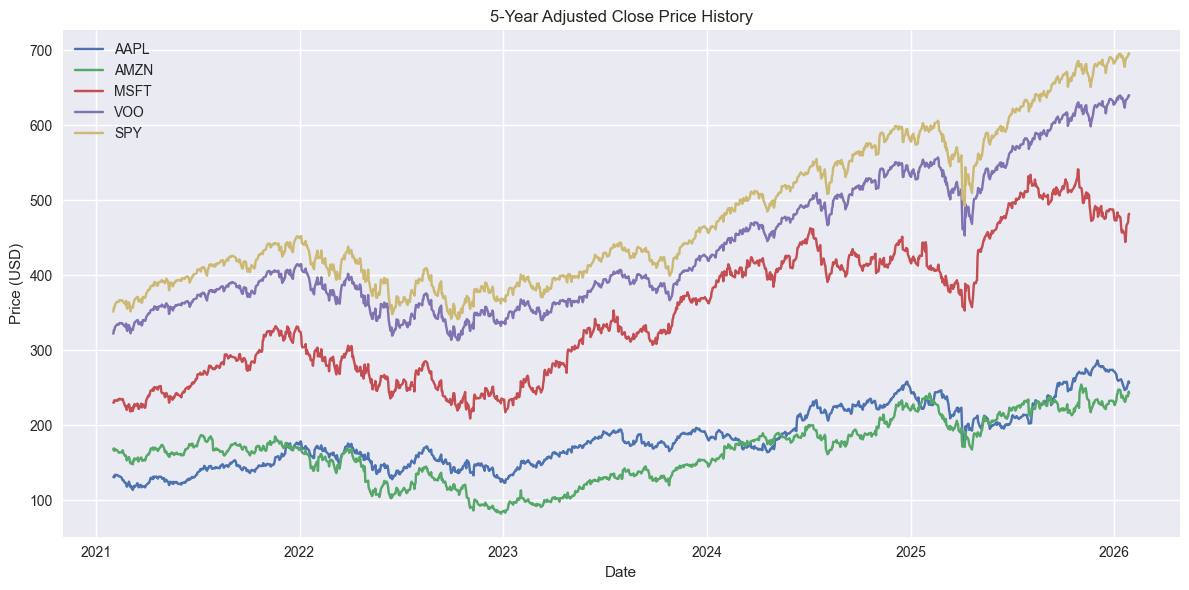

In [70]:
# Price history for each ticker (Adj Close)
price_cols = [c for c in clean_prices.columns if c.startswith("Adj_Close_")]

plt.figure(figsize=(12, 6))
for col in price_cols:
    plt.plot(clean_prices.index, clean_prices[col], label=col.replace("Adj_Close_", ""))

plt.title("5-Year Adjusted Close Price History")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/price_history_adj_close.png", dpi=150)
plt.show()

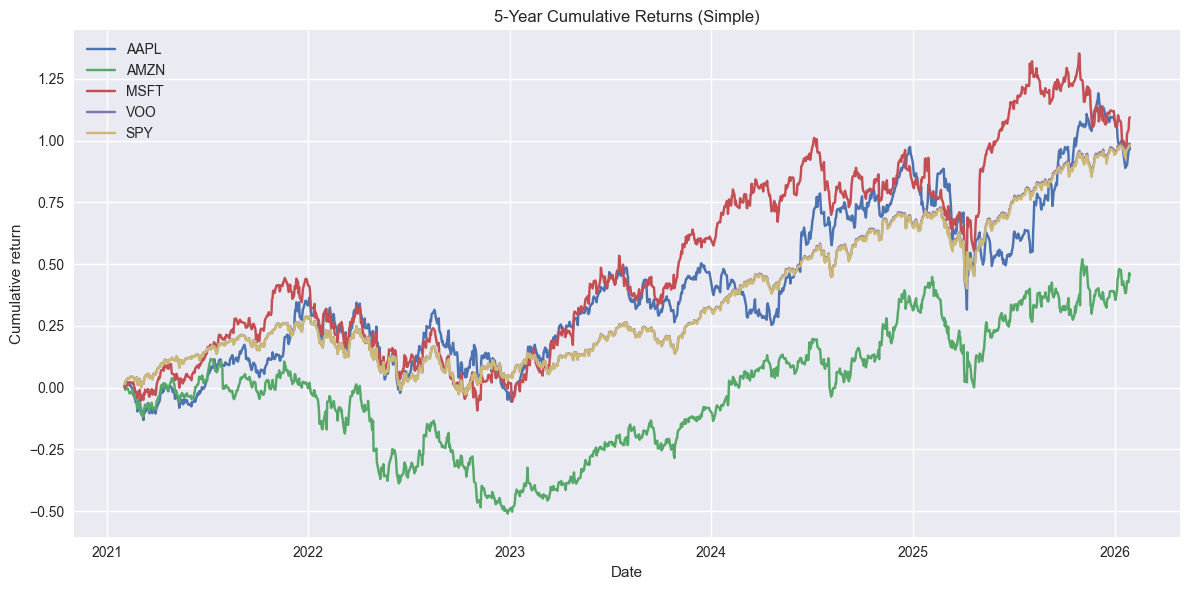

In [71]:
# Cumulative simple returns from daily returns
ret_cols = [c for c in eda_df.columns if c.startswith("ret_")]
cumrets = (1 + eda_df[ret_cols]).cumprod() - 1

plt.figure(figsize=(12, 6))
for col in ret_cols:
    plt.plot(eda_df.index, cumrets[col], label=col.replace("ret_", ""))

plt.title("5-Year Cumulative Returns (Simple)")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/cumulative_returns_simple.png", dpi=150)
plt.show()


In [74]:
# Summary statistics for daily simple returns
ret_cols = [c for c in eda_df.columns if c.startswith("ret_")]

ret_summary = eda_df[ret_cols].describe().T  # rows = tickers
ret_summary_simple = ret_summary[["mean", "std", "min", "max"]]
ret_summary_simple


,mean,std,min,max
ret_AAPL,0.000689,0.017400,-0.092456,0.153289
ret_AMZN,0.000543,0.022112,-0.140494,0.135359
ret_MSFT,0.000720,0.016148,-0.077156,0.101337
ret_VOO,0.000604,0.010582,-0.057957,0.092744
ret_SPY,0.000603,0.010735,-0.058543,0.105019


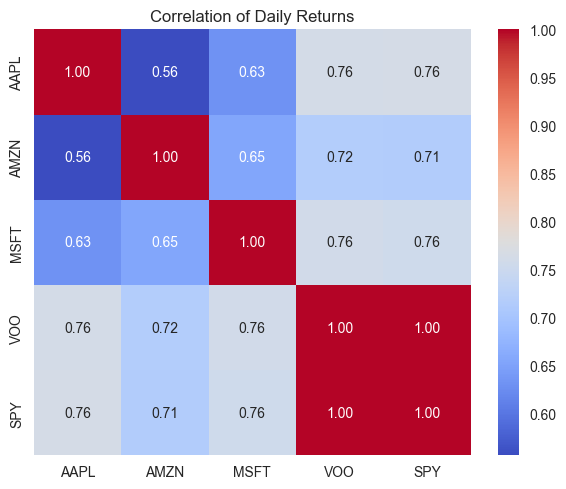

In [75]:
# Correlation matrix of daily returns
corr = eda_df[ret_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=[c.replace("ret_", "") for c in ret_cols],
    yticklabels=[c.replace("ret_", "") for c in ret_cols],
)
plt.title("Correlation of Daily Returns")
plt.tight_layout()
plt.savefig("../reports/figures/returns_correlation_heatmap.png", dpi=150)
plt.show()